In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [3]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [3]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [5]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [5]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [7]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [6]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [9]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


In [7]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [11]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [8]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [13]:
print(fund_master.columns)
print(nav.columns)
print(aum.columns)
print(sip.columns)
print(category.columns)
print(folio.columns)
print(performance.columns)
print(transactions.columns)
print(portfolio.columns)
print(benchmark.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_r

In [9]:
# Display column names of all datasets

print("Fund Master")
print(fund_master.columns)

print("\nNAV History")
print(nav.columns)

print("\nAUM")
print(aum.columns)

print("\nSIP")
print(sip.columns)

print("\nCategory Inflows")
print(category.columns)

print("\nFolio Count")
print(folio.columns)

print("\nScheme Performance")
print(performance.columns)

print("\nTransactions")
print(transactions.columns)

print("\nPortfolio")
print(portfolio.columns)

print("\nBenchmark")
print(benchmark.columns)

Fund Master
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

NAV History
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category Inflows
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Folio Count
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Scheme Performance
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 're

In [15]:
# Check dataset information

fund_master.info()

nav.info()

aum.info()

sip.info()

category.info()

folio.info()

performance.info()

transactions.info()

portfolio.info()

benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB
<class 'pandas.D

In [10]:
# Check missing values

print(fund_master.isnull().sum())

print(nav.isnull().sum())

print(aum.isnull().sum())

print(sip.isnull().sum())

print(category.isnull().sum())

print(folio.isnull().sum())

print(performance.isnull().sum())

print(transactions.isnull().sum())

print(portfolio.isnull().sum())

print(benchmark.isnull().sum())

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64
amfi_code    0
date         0
nav          0
dtype: int64
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64
month               0
category            0
net_inflow_crore    0
dtype: int64
month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64
amfi_code

In [17]:
# Display statistical summary

display(nav.describe())

display(aum.describe())

display(sip.describe())

display(performance.describe())

display(transactions.describe())

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,36.000000
mean,19577.520833,7.189583,9.893750,8.632083,31.456944
std,6354.329621,1.271457,5.370745,3.613579,11.768190
min,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,25944.250000,8.300000,9.562500,10.525000,40.807500
max,31002.000000,9.350000,46.000000,15.900000,53.050000


,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


,amfi_code,amount_inr,annual_income_lakh
count,32778.000000,32778.000000,32778.000000
mean,120264.617518,107437.318628,26.181219
std,14370.205345,150415.905084,20.805425
min,100016.000000,400.000000,3.000000
25%,118632.000000,3153.000000,10.600000
50%,119551.000000,17782.500000,19.700000
75%,120843.000000,189324.250000,37.400000
max,149324.000000,597498.000000,99.700000




## NAV Trend Analysis



In [11]:
# Convert date column into datetime

nav['date']=pd.to_datetime(nav['date'])

# Plot NAV trend

fig=px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend'
)

# Highlight 2023 Bull Run

fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    fillcolor='green',
    opacity=0.20,
    annotation_text='Bull Run'
)

# Highlight 2024 Correction

fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    fillcolor='red',
    opacity=0.20,
    annotation_text='Correction'
)

fig.show()

In [12]:
# Save NAV chart

fig.write_image("../reports/nav_trend.png")



## AUM Growth by Fund House

In [13]:
# Plot AUM growth

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_cr',
    hue='fund_house'
)

plt.title("AUM Growth")

plt.xticks(rotation=45)

plt.savefig("../reports/aum_growth.png")

plt.show()

ValueError: Could not interpret value `year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [14]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [15]:
# Convert date column to datetime

aum['date'] = pd.to_datetime(aum['date'])

In [16]:
# Extract year from date

aum['year'] = aum['date'].dt.year

In [17]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


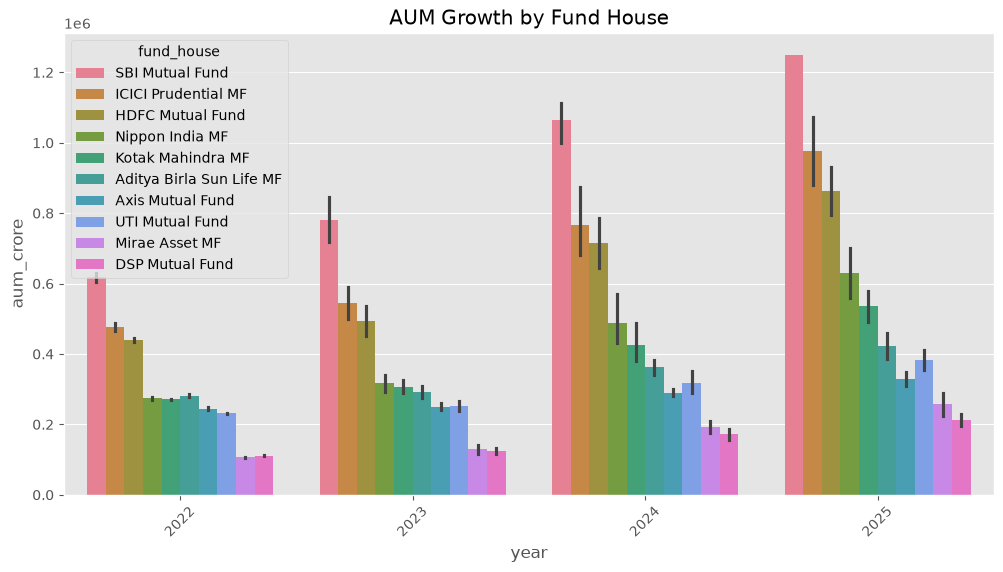

In [18]:
# Create figure

plt.figure(figsize=(12,6))

# Draw grouped bar chart

sns.barplot(
    data=aum,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

# Chart title

plt.title("AUM Growth by Fund House")

# Rotate labels

plt.xticks(rotation=45)

# Save chart

plt.savefig("../reports/aum_growth.png", dpi=300, bbox_inches='tight')

# Display chart

plt.show()

In [19]:
# Plot SIP trend

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

# Add highest SIP annotation

fig.add_annotation(
    x="2025-12",
    y=31002,
    text="₹31,002 Cr",
    showarrow=True
)

fig.show()

# Save chart
fig.write_image("../reports/sip_trend.png")

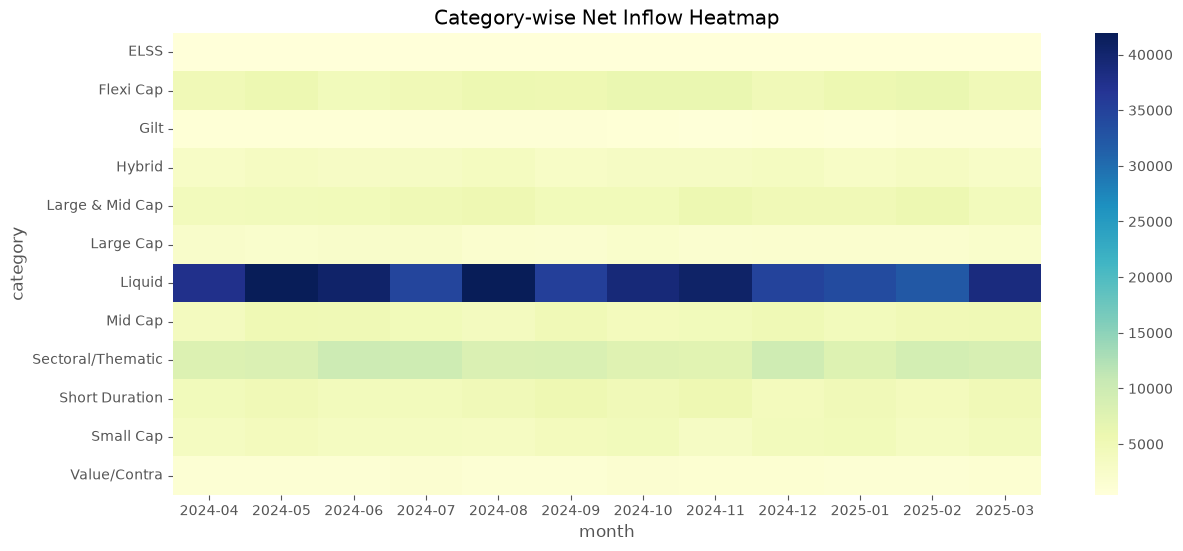

In [20]:
# Create pivot table

pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

# Plot heatmap

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")

# Save chart
plt.savefig("../reports/category_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

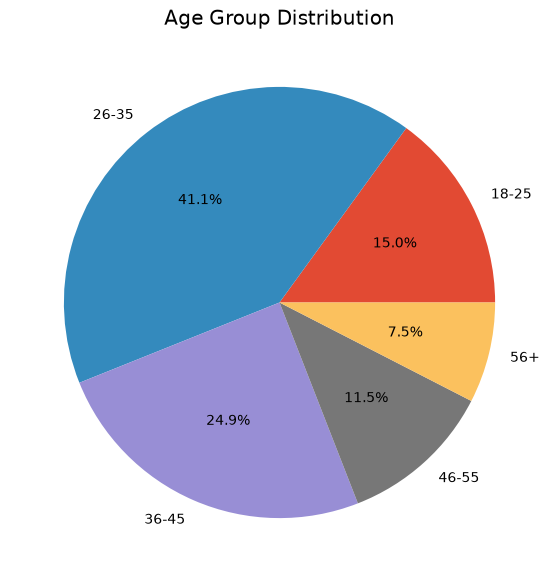

In [21]:
# Age group distribution

age = transactions.groupby("age_group").size()

plt.figure(figsize=(7,7))

plt.pie(
    age,
    labels=age.index,
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

# Save chart
plt.savefig("../reports/age_group_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

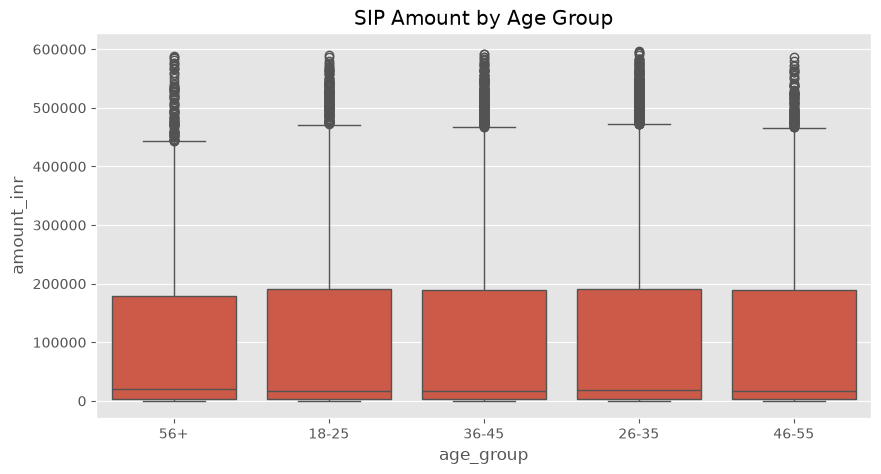

In [22]:
# SIP amount by age group

plt.figure(figsize=(10,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

# Save chart
plt.savefig("../reports/sip_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

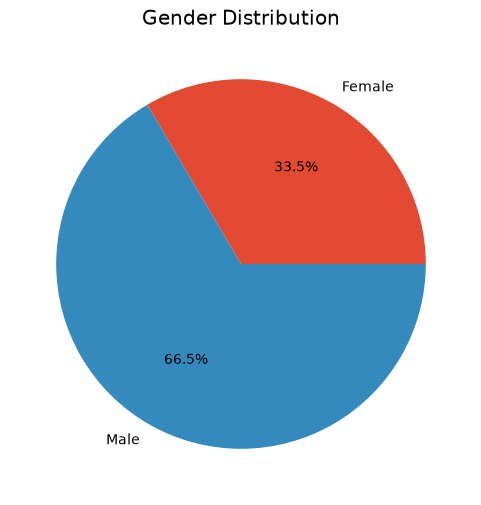

In [23]:
# Gender distribution

gender = transactions.groupby("gender").size()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

# Save chart
plt.savefig("../reports/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

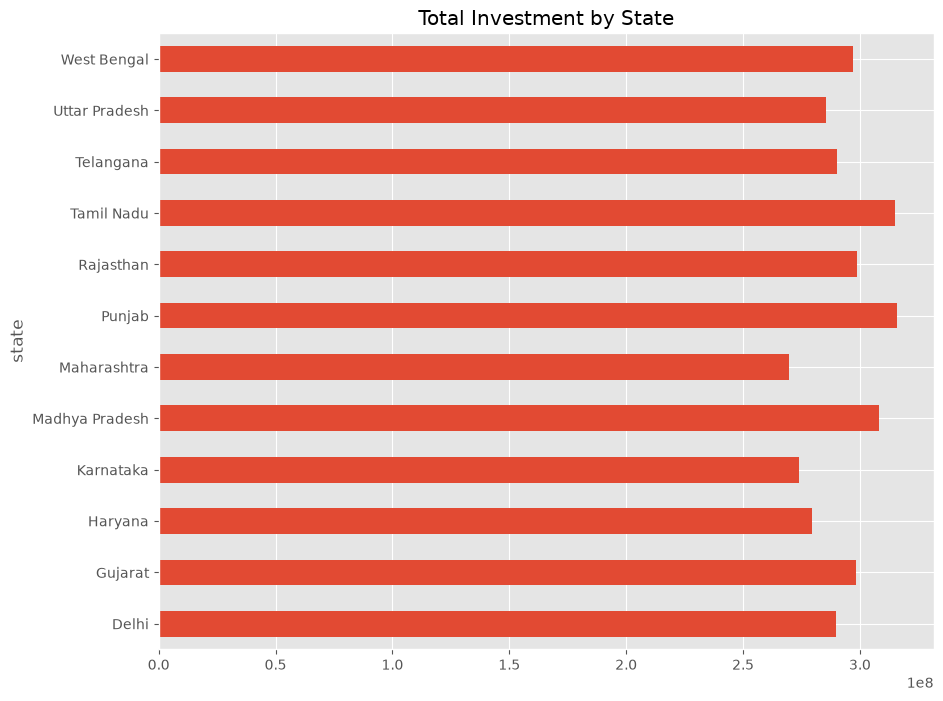

In [24]:
# Total investment by state

state = transactions.groupby("state")["amount_inr"].sum()

plt.figure(figsize=(10,8))

state.plot(kind="barh")

plt.title("Total Investment by State")

# Save chart
plt.savefig("../reports/state_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

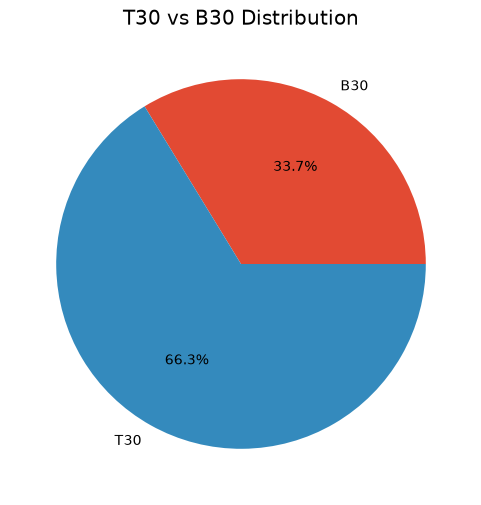

In [25]:
# T30 vs B30

tier = transactions.groupby("city_tier").size()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

# Save chart
plt.savefig("../reports/t30_b30.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
# Industry folio growth

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth"
)

fig.show()

# Save chart
fig.write_image("../reports/folio_growth.png")

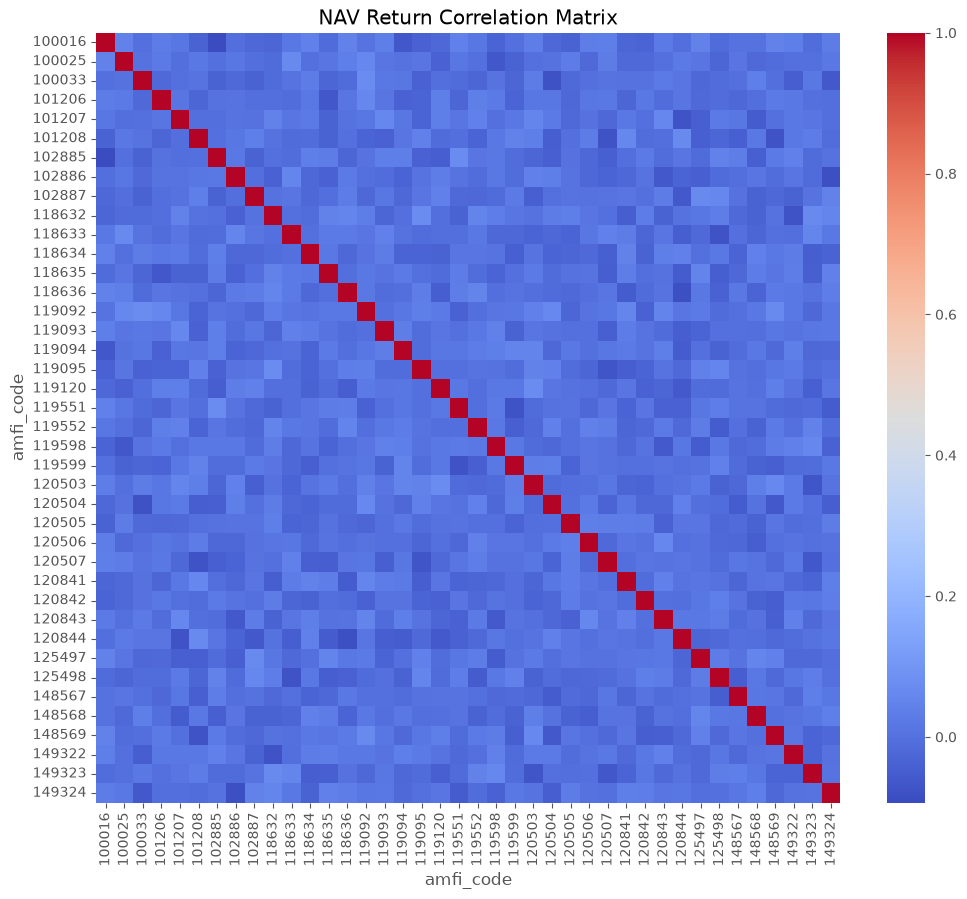

In [27]:
# Calculate daily returns

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

# Save chart
plt.savefig("../reports/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

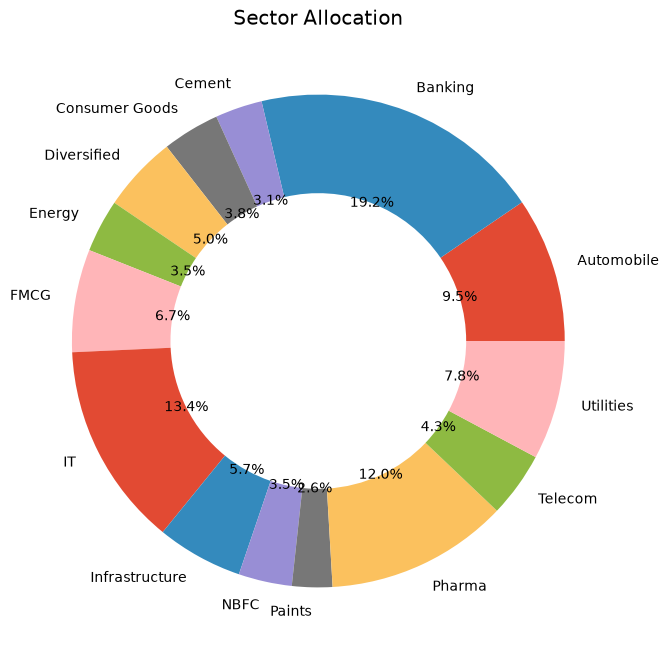

In [28]:
# Sector allocation donut chart

sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

# Save chart
plt.savefig("../reports/sector_allocation.png", dpi=300, bbox_inches="tight")

plt.show()

# EDA Findings

1. NAV showed strong growth during the 2023 market rally.

2. SBI had the highest AUM among fund houses.

3. December 2025 recorded the highest SIP inflow.

4. Equity category attracted the highest inflows.

5. Most investors belong to the 26–35 age group.

6. Male investors contributed more transactions.

7. Maharashtra had the highest investment amount.

8. T30 cities accounted for a larger share of investments.

9. Technology and Financial sectors had the highest portfolio allocation.

10. Large-cap funds showed strong positive return correlations.